# Filipino Family Income and Expenditure Survey
## Uncovering Stories from Data

A collaborative data storytelling project analyzing the 2021 Philippine Family Income and Expenditure Survey (FIES) dataset published by the Philippine Statistics Authority (PSA).

**Team:** Euie · James · JB · John · Matt  
**Bootcamp:** Uplift Code Camp — Python for Data and AI (2026)

**Dataset:** [PSA FIES 2021](https://psa.gov.ph/statistics/income-expenditure/fies) — 41,544 households · 64 features

---

### Analysis Themes
1. Urban vs. Rural Differences
2. Impact of Education on Income
3. Household Size and Spending
4. Gender Differences in Household Economics
5. Regional Spending Patterns
6. Personal Exploration — Impact of Lifestyle on Cost of Living

## Setup & Imports

In [57]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('Libraries imported successfully.')

Libraries imported successfully.


## Load Dataset

In [58]:
# Mount Google Drive if running in Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
# Update this path to match your Drive location
df = pd.read_csv('/content/drive/MyDrive/Uplift - Python for Data and AI/0311 Data Analytics Activity/Family Income and Expenditure_edited.csv')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Dataset loaded: 41,544 rows × 63 columns


,Annual Household Income,Region,Total Food Expenditure,Main Source of Income,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,...,"Number of Car, Jeep, Van",Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle,Monthly Income,Total Expenditure,Total Monthly Expenditure
0,480332,CAR,117848,Wage/Salaries,0,42140,38300,24676,16806,3325,...,0,0,2,1,0,0,1,40027.67,327030,27252.50
1,198235,CAR,67766,Wage/Salaries,0,17329,13008,17434,11073,2035,...,0,0,3,1,0,0,2,16519.58,211888,17657.33
2,82785,CAR,61609,Wage/Salaries,1,34182,32001,7783,2590,1730,...,0,0,0,0,0,0,0,6898.75,103413,8617.75


In [60]:
# Create Income Brackets column on main df (used across multiple themes)
bins = [0, 132_000, 264_000, 528_000, 924_000, 1_572_000, 2_628_000, float('inf')]
labels = ['Poor', 'Low Income', 'Lower Middle', 'Middle Income',
          'Upper Middle', 'Upper Middle not Rich', 'Rich']
df['Income Brackets'] = pd.cut(df['Annual Household Income'], bins=bins, labels=labels)
print('Income Brackets created.')

Income Brackets created.


---
## Theme 1 — Urban vs. Rural Differences
**By:** James  
**Question:** How do household incomes and expenditures differ between urban and rural households?

> **Finding:** NCR shows a consumption-driven pattern — low-income households overspend relative to income. Eastern Visayas reflects restrained spending, with households consistently spending below income especially at higher brackets.

In [61]:
# Income bracket bins and labels
bins = [0, 132_000, 264_000, 528_000, 924_000, 1_572_000, 2_628_000, float('inf')]
labels = ['Poor', 'Low Income', 'Lower Middle', 'Middle Income',
          'Upper Middle', 'Upper Middle not Rich', 'Rich']

# Urban (NCR) — average income and expenditure by bracket
urban_df = df[df['Region'] == 'NCR'].copy()
urban_df['Income Bracket'] = pd.cut(urban_df['Annual Household Income'], bins=bins, labels=labels)
summary_df = (
    urban_df.groupby('Income Bracket')[['Annual Household Income', 'Total Expenditure']]
    .mean().round(2).reset_index()
)
summary_df

,Income Bracket,Annual Household Income,Total Expenditure
0,Poor,102868.52,132141.08
1,Low Income,198776.17,226004.41
2,Lower Middle,371226.56,372991.53
3,Middle Income,685871.06,637947.56
4,Upper Middle,1141796.34,969129.13
5,Upper Middle not Rich,2024821.18,1506951.32
6,Rich,3485836.88,2466226.76


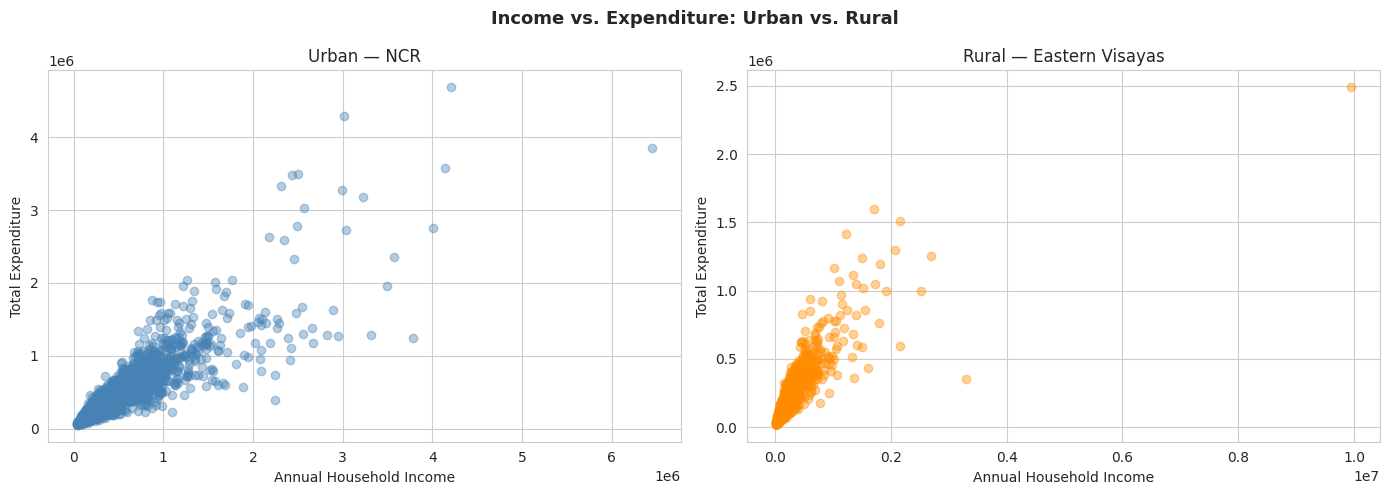

In [62]:
# Scatter: Urban NCR — Income vs. Expenditure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

urban_df = df[df['Region'] == 'NCR']
axes[0].scatter(urban_df['Annual Household Income'], urban_df['Total Expenditure'], alpha=0.4, color='steelblue')
axes[0].set_xlabel('Annual Household Income')
axes[0].set_ylabel('Total Expenditure')
axes[0].set_title('Urban — NCR')

rural_df = df[df['Region'] == 'VIII - Eastern Visayas']
axes[1].scatter(rural_df['Annual Household Income'], rural_df['Total Expenditure'], alpha=0.4, color='darkorange')
axes[1].set_xlabel('Annual Household Income')
axes[1].set_ylabel('Total Expenditure')
axes[1].set_title('Rural — Eastern Visayas')

plt.suptitle('Income vs. Expenditure: Urban vs. Rural', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Theme 2 — Impact of Education on Income
**By:** Euie  
**Question:** Do household heads with higher education levels earn more?

> **Finding:** Higher education is strongly linked to better income. Household heads with no grade completed earn significantly less than those with college or postgraduate education.

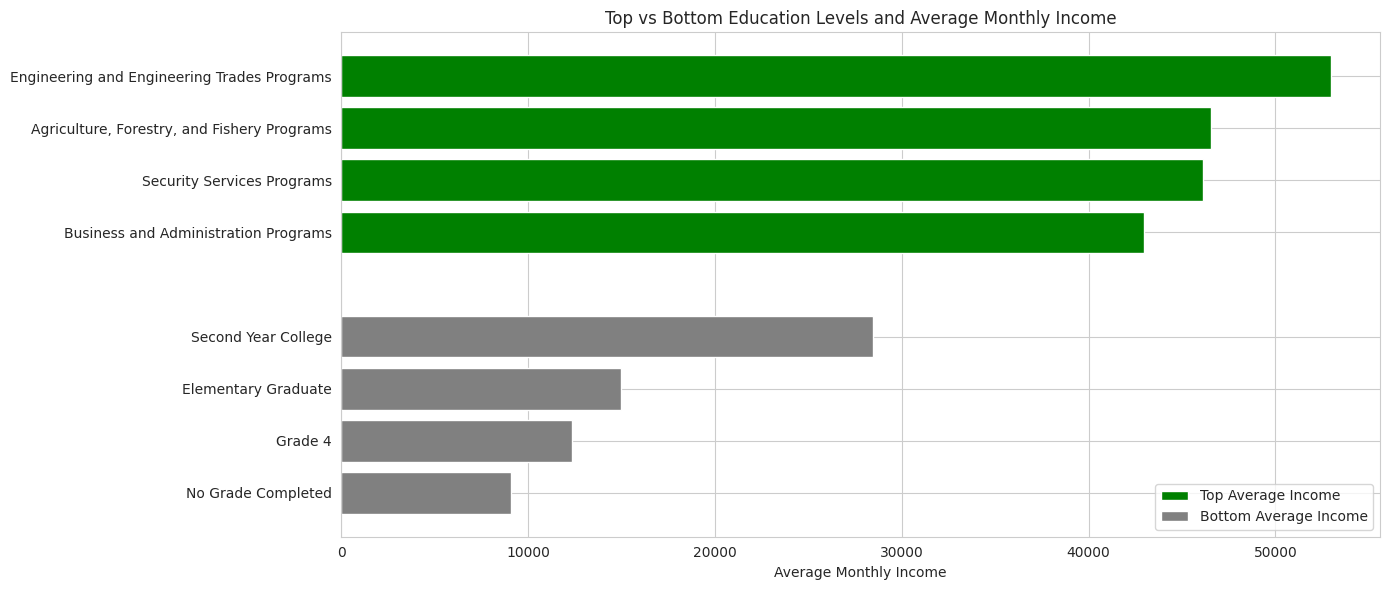

In [63]:
top5_high = (df[['Household Head Highest Grade Completed', 'Monthly Income']]
             .sort_values(by='Monthly Income', ascending=False).head(5))
top5_high_mean_income = (
    df[df['Household Head Highest Grade Completed']
       .isin(top5_high['Household Head Highest Grade Completed'])]
    .groupby('Household Head Highest Grade Completed')['Monthly Income']
    .mean().round(2)
)
bottom5 = (df[['Household Head Highest Grade Completed', 'Monthly Income']]
           .sort_values(by='Monthly Income', ascending=False).tail(5))
bottom5_low_mean_income = (
    df[df['Household Head Highest Grade Completed']
       .isin(bottom5['Household Head Highest Grade Completed'])]
    .groupby('Household Head Highest Grade Completed')['Monthly Income']
    .mean().round(2)
)
high = top5_high_mean_income.sort_values(ascending=False)
low = bottom5_low_mean_income.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
y_high = np.arange(len(high.values))
y_low = np.arange(len(low.values)) + len(high.values) + 1
ax.barh(y_high, high.values, color='green', label='Top Average Income')
ax.barh(y_low, low.values, color='gray', label='Bottom Average Income')
ax.set_yticks(list(y_high) + list(y_low))
ax.set_yticklabels(list(high.index) + list(low.index))
ax.set_xlabel('Average Monthly Income')
ax.set_title('Top vs Bottom Education Levels and Average Monthly Income')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

---
## Theme 3 — Household Size and Spending
**By:** John  
**Question:** Do larger families spend more on food or education?

> **Finding:** Large families spend more in absolute terms, but the proportion of income allocated to food and education does not increase significantly — shared expenses dilute the per-capita burden.

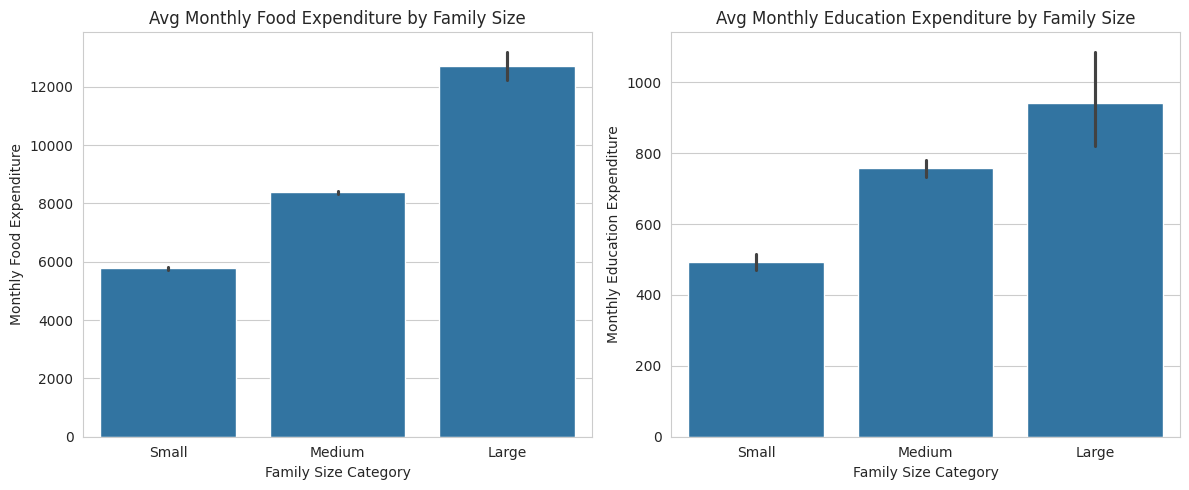

In [64]:
df['Family Size Category'] = pd.cut(
    df['Total Number of Family members'],
    bins=[0, 4, 10, 30], labels=['Small', 'Medium', 'Large']
)
filt_food = df['Total Food Expenditure'] / 12
filt_edu = df['Education Expenditure'] / 12

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=df, x='Family Size Category', y=filt_food, ax=axes[0])
axes[0].set_ylabel('Monthly Food Expenditure')
axes[0].set_title('Avg Monthly Food Expenditure by Family Size')
sns.barplot(data=df, x='Family Size Category', y=filt_edu, ax=axes[1])
axes[1].set_ylabel('Monthly Education Expenditure')
axes[1].set_title('Avg Monthly Education Expenditure by Family Size')
plt.tight_layout()
plt.show()

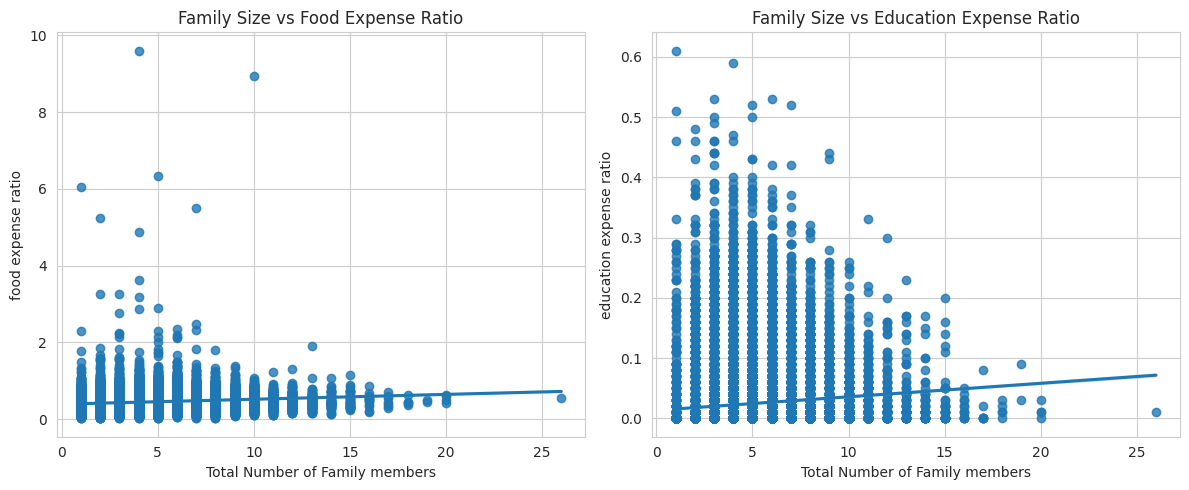

In [65]:
df['food expense ratio'] = ((df['Total Food Expenditure'] / 12) / df['Monthly Income']).round(2)
df['education expense ratio'] = ((df['Education Expenditure'] / 12) / df['Monthly Income']).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(data=df, x='Total Number of Family members', y='food expense ratio', ax=axes[0])
axes[0].set_title('Family Size vs Food Expense Ratio')
sns.regplot(data=df, x='Total Number of Family members', y='education expense ratio', ax=axes[1])
axes[1].set_title('Family Size vs Education Expense Ratio')
plt.tight_layout()
plt.show()

---
## Theme 4 — Gender Differences in Household Economics
**By:** Matt  
**Question:** Is there a difference in spending patterns based on the sex of the household head?

> **Finding:** Female-headed households spend more on housing, medical care, education, and communication. Male-headed households spend more on staple foods, agriculture, tobacco, and alcohol.

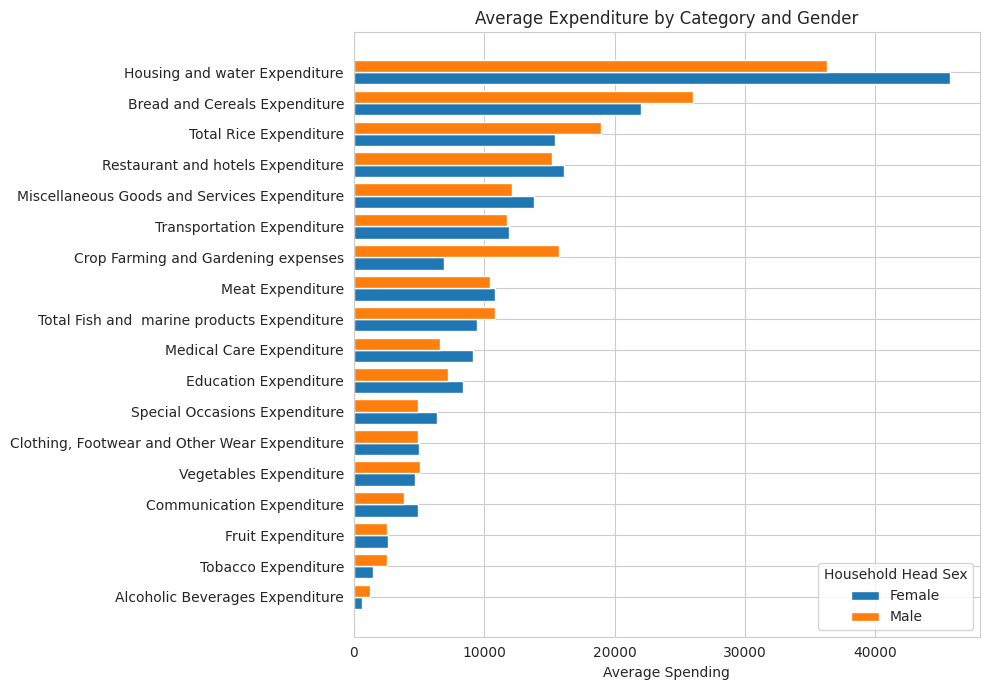

In [66]:
exp_cols = [
    'Bread and Cereals Expenditure', 'Total Rice Expenditure', 'Meat Expenditure',
    'Total Fish and  marine products Expenditure', 'Fruit Expenditure',
    'Vegetables Expenditure', 'Restaurant and hotels Expenditure',
    'Alcoholic Beverages Expenditure', 'Tobacco Expenditure',
    'Clothing, Footwear and Other Wear Expenditure', 'Housing and water Expenditure',
    'Medical Care Expenditure', 'Transportation Expenditure', 'Communication Expenditure',
    'Education Expenditure', 'Miscellaneous Goods and Services Expenditure',
    'Special Occasions Expenditure', 'Crop Farming and Gardening expenses'
]
avg_exp = df.groupby('Household Head Sex')[exp_cols].mean().T
avg_exp['Total'] = avg_exp.mean(axis=1)
avg_exp = avg_exp.sort_values('Total', ascending=True).drop(columns='Total')

plt.figure(figsize=(10, 7))
y = range(len(avg_exp))
plt.barh(y, avg_exp['Female'], height=0.4, label='Female')
plt.barh([i + 0.4 for i in y], avg_exp['Male'], height=0.4, label='Male')
plt.yticks([i + 0.2 for i in y], avg_exp.index)
plt.xlabel('Average Spending')
plt.title('Average Expenditure by Category and Gender')
plt.legend(title='Household Head Sex')
plt.tight_layout()
plt.show()

---
## Theme 5 — Regional Spending Patterns
**By:** JB  
**Question:** Which regions spend the most on education, transportation, and food?

> **Finding:** NCR leads all regions in food, education, and transportation spending. ARMM and Northern Mindanao are consistently at the bottom across all three categories.

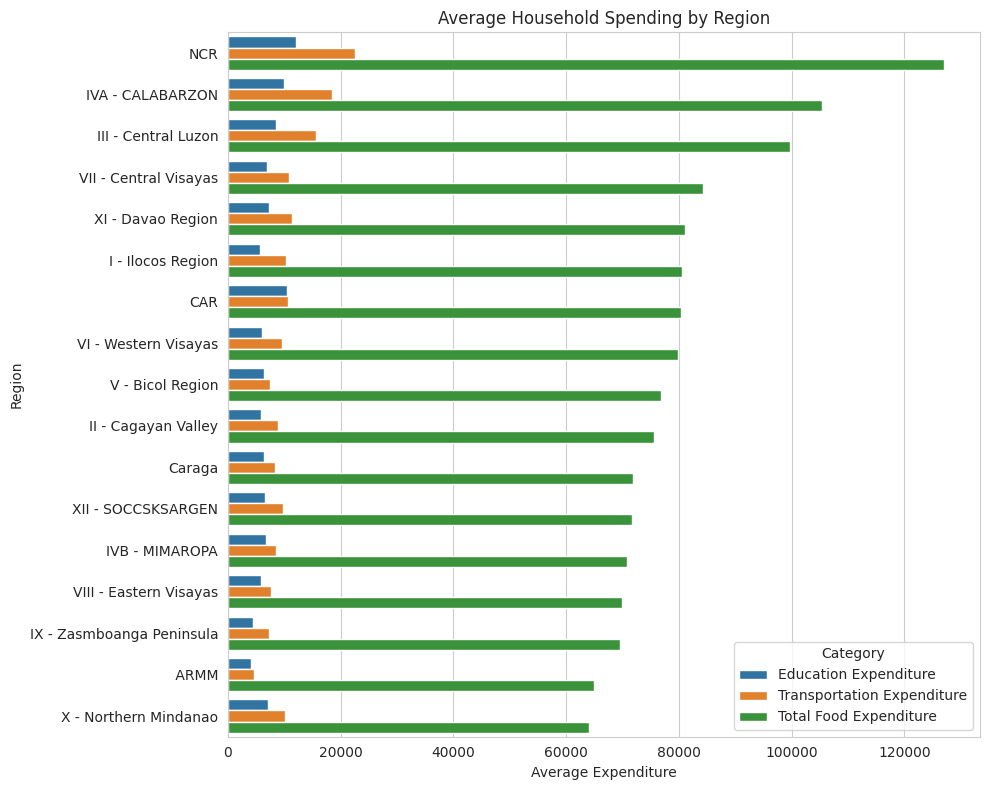

In [67]:
regional_spending = df.groupby('Region')[
    ['Education Expenditure', 'Transportation Expenditure', 'Total Food Expenditure']
].mean().reset_index()
regional_spending = regional_spending.sort_values('Total Food Expenditure', ascending=False)
df_regional = regional_spending.melt(id_vars='Region', var_name='Category', value_name='Expenditure')

plt.figure(figsize=(10, 8))
sns.barplot(data=df_regional, x='Expenditure', y='Region', hue='Category')
plt.title('Average Household Spending by Region')
plt.xlabel('Average Expenditure')
plt.ylabel('Region')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

---
## Theme 6 — Impact of Lifestyle on Household Cost of Living
**By:** All members  

Five lifestyle factors examined: Special Occasions · Vehicle Ownership · Tenure Status · Clothing · Tobacco & Alcohol

### 6a. Special Occasions Expenditure *(JB)*
> Most households spend very little on special occasions. The relationship with total cost of living is weak with notable outliers at the high end.

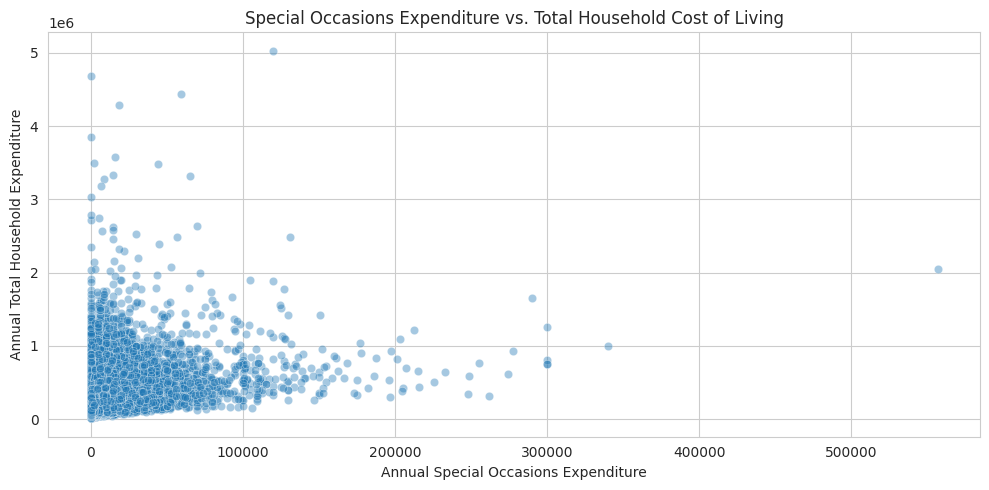

In [68]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Special Occasions Expenditure', y='Total Expenditure', alpha=0.4)
plt.title('Special Occasions Expenditure vs. Total Household Cost of Living')
plt.xlabel('Annual Special Occasions Expenditure')
plt.ylabel('Annual Total Household Expenditure')
plt.tight_layout()
plt.show()

### 6b. Vehicle Ownership by Social Class *(Matt)*
> Vehicle ownership rises sharply with income. Rich households average ~2 vehicles; poor households rarely own any.

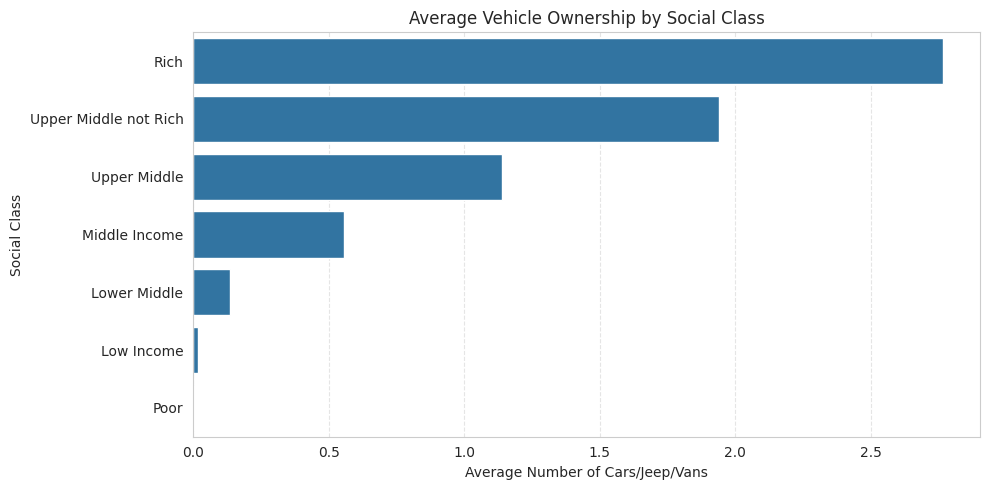

In [69]:
bins = [0, 132000, 264000, 528000, 924000, 1572000, 2628000, 9999999999999]
labels = ['Poor', 'Low Income', 'Lower Middle', 'Middle Income',
          'Upper Middle', 'Upper Middle not Rich', 'Rich']
df['Social Class'] = pd.cut(df['Total Expenditure'], bins=bins, labels=labels)
car_by_class = (
    df.groupby('Social Class', observed=False)['Number of Car, Jeep, Van']
    .mean().reset_index()
    .sort_values('Number of Car, Jeep, Van', ascending=False)
)
sns.barplot(data=car_by_class, y='Social Class', x='Number of Car, Jeep, Van',
            order=car_by_class['Social Class'])
plt.title('Average Vehicle Ownership by Social Class')
plt.xlabel('Average Number of Cars/Jeep/Vans')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 6c. Tenure Status by Income Bracket *(John)*
> Housing security improves with income. Higher-income households are more likely to fully own their homes.

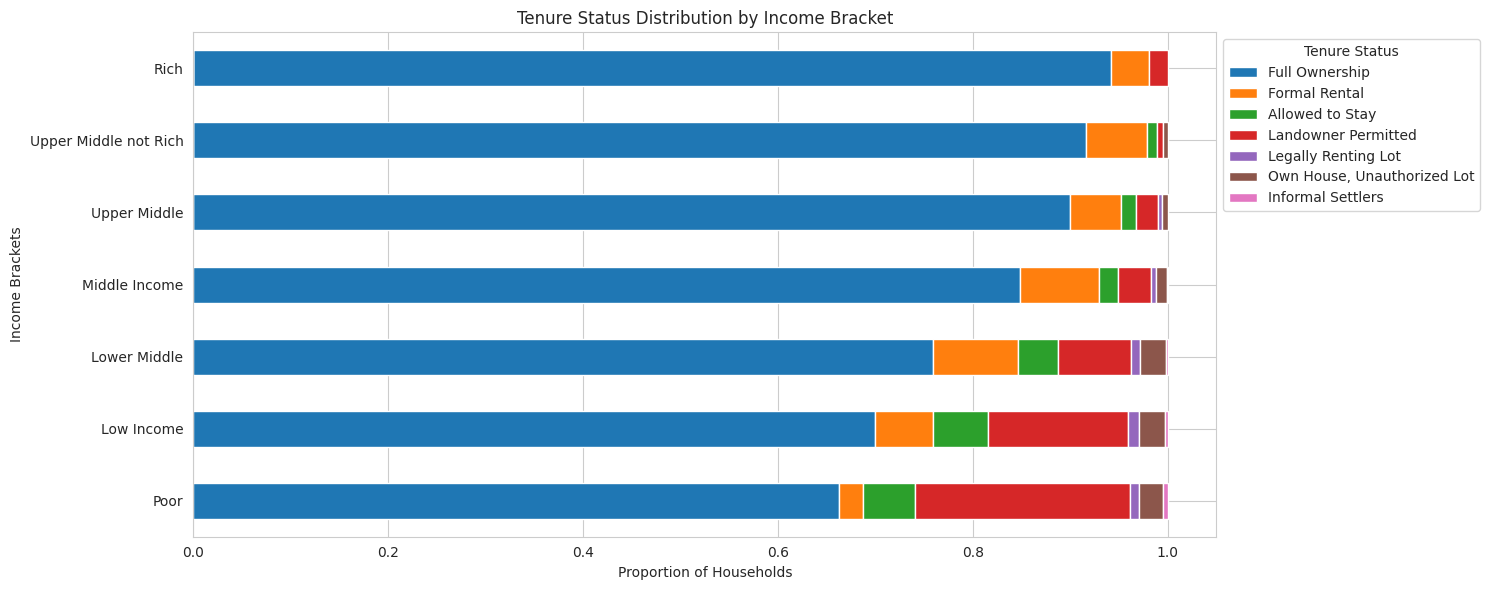

In [70]:
df_tenure = df[df['Tenure Status'] != 'Not Applicable'].copy()
tenure_map = {
    'Own or owner-like possession of house and lot': 'Full Ownership',
    'Rent-free house and lot with consent of owner': 'Allowed to Stay',
    'Own house, rent-free lot with consent of owner': 'Landowner Permitted',
    'Own house, rent lot': 'Legally Renting Lot',
    'Rent house/room including lot': 'Formal Rental',
    'Own house, rent-free lot without consent of owner': 'Own House, Unauthorized Lot',
    'Rent-free house and lot without consent of owner': 'Informal Settlers'
}
df_tenure['Clear Tenure Status'] = df_tenure['Tenure Status'].map(tenure_map)
income_order = ['Poor', 'Low Income', 'Lower Middle', 'Middle Income',
                'Upper Middle', 'Upper Middle not Rich', 'Rich']
legend_order = ['Full Ownership', 'Formal Rental', 'Allowed to Stay',
                'Landowner Permitted', 'Legally Renting Lot',
                'Own House, Unauthorized Lot', 'Informal Settlers']
tenure_income = pd.crosstab(df_tenure['Income Brackets'], df_tenure['Clear Tenure Status'])
tenure_income = tenure_income.div(tenure_income.sum(axis=1), axis=0)[legend_order]
tenure_income.loc[income_order].plot(kind='barh', stacked=True, figsize=(15, 6))
plt.legend(title='Tenure Status', bbox_to_anchor=(1, 1), loc='upper left')
plt.title('Tenure Status Distribution by Income Bracket')
plt.ylabel('Income Brackets')
plt.xlabel('Proportion of Households')
plt.tight_layout()
plt.show()

### 6d. Clothing Expenditure by Income Bracket *(James)*
> Middle brackets peak at ~2.5–2.6% of expenditure on clothing. Rich households spend more in absolute terms but proportionally less of their income.

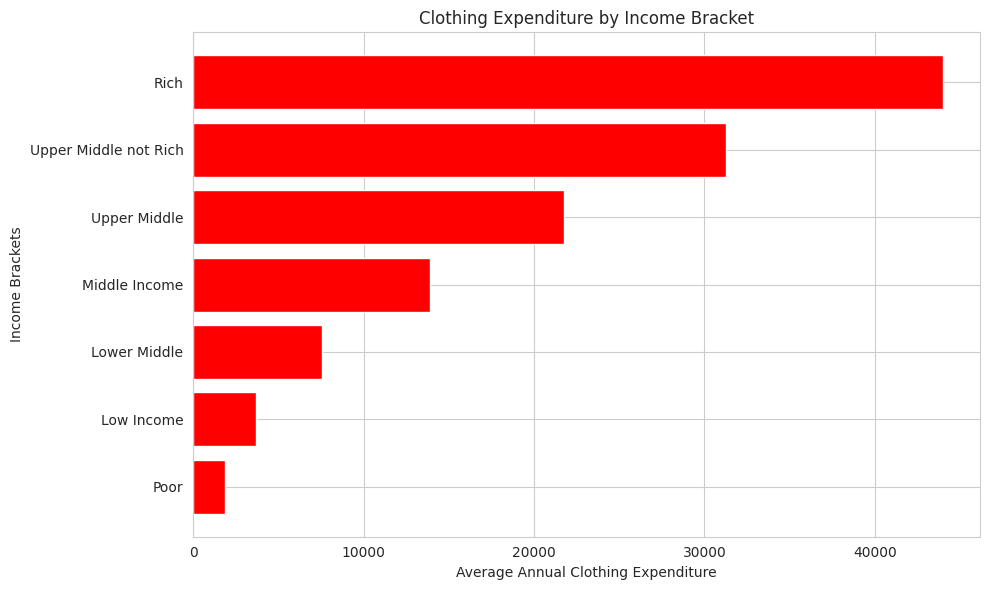

In [71]:
clothing_df = df.copy()
clothing_df['Income Brackets'] = pd.cut(clothing_df['Annual Household Income'], bins=bins, labels=labels)
clothing_summary = (
    clothing_df.groupby('Income Brackets')['Clothing, Footwear and Other Wear Expenditure']
    .mean().round(2).reset_index()
)
plt.figure(figsize=(10, 6))
plt.barh(clothing_summary['Income Brackets'],
         clothing_summary['Clothing, Footwear and Other Wear Expenditure'],
         color='red')
plt.xlabel('Average Annual Clothing Expenditure')
plt.ylabel('Income Brackets')
plt.title('Clothing Expenditure by Income Bracket')
plt.tight_layout()
plt.show()

### 6e. Tobacco & Alcohol Expenditure *(Euie)*
> Upper-middle households spend the most on vices. Tobacco is more accessible than alcohol across all brackets due to Sin Tax (RA 10351) pricing — tobacco is cheap and sold in singles; alcohol is expensive and sold in bottles.

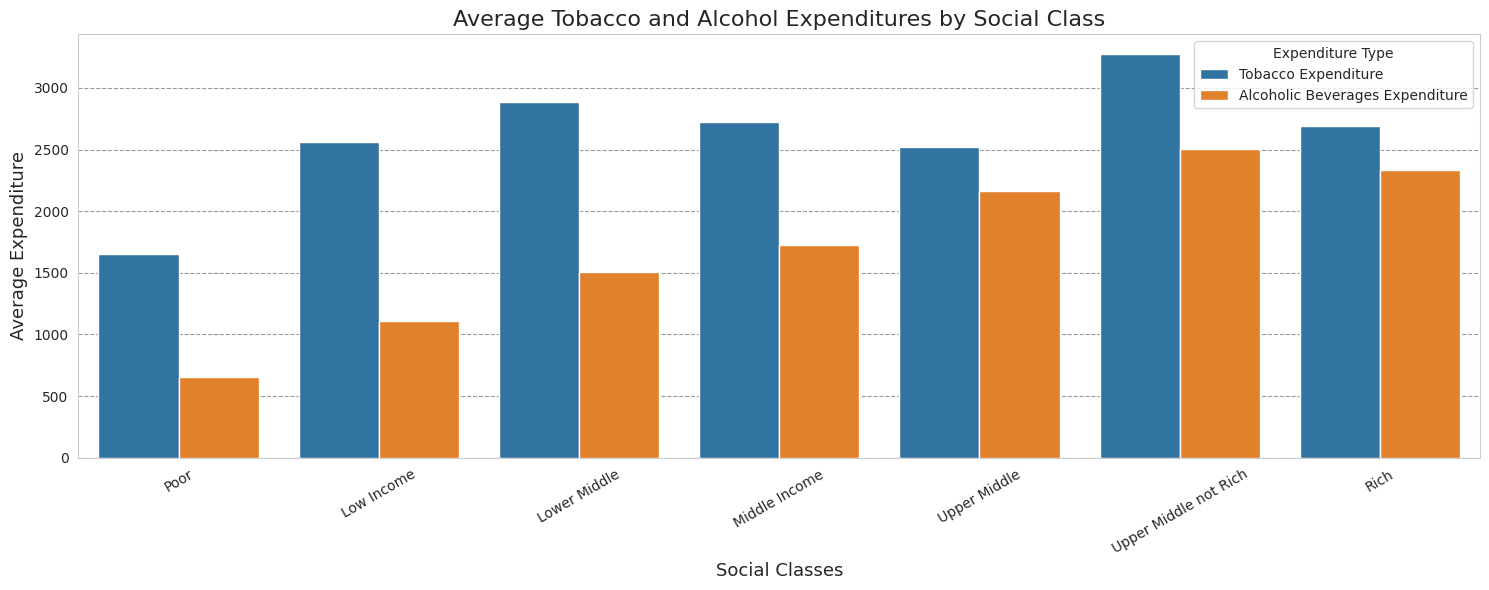

In [72]:
bins = [0, 132_000, 264_000, 528_000, 924_000, 1_572_000, 2_628_000, float('inf')]
labels = ['Poor', 'Low Income', 'Lower Middle', 'Middle Income',
          'Upper Middle', 'Upper Middle not Rich', 'Rich']
vices_df = df.copy()
vices_df['Income Bracket'] = pd.cut(vices_df['Annual Household Income'], bins=bins, labels=labels)
summary_df = (
    vices_df.groupby('Income Bracket')[['Tobacco Expenditure', 'Alcoholic Beverages Expenditure']]
    .mean().round(2).reset_index()
)
summary_df['Income Bracket'] = pd.Categorical(summary_df['Income Bracket'], categories=labels, ordered=True)
summary_df = summary_df.sort_values('Income Bracket')
plot_df = summary_df.melt(
    id_vars='Income Bracket',
    value_vars=['Tobacco Expenditure', 'Alcoholic Beverages Expenditure'],
    var_name='Expenditure Type', value_name='Average Expenditure'
)
plt.figure(figsize=(15, 6))
sns.barplot(data=plot_df, x='Income Bracket', y='Average Expenditure', hue='Expenditure Type')
plt.title('Average Tobacco and Alcohol Expenditures by Social Class', fontsize=16)
plt.xlabel('Social Classes', fontsize=13)
plt.ylabel('Average Expenditure', fontsize=13)
plt.xticks(rotation=30)
plt.grid(visible=True, axis='y', linestyle='--', color='black', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Summary

| Theme | Key Finding |
|---|---|
| Urban vs. Rural | NCR is consumption-driven; Eastern Visayas is savings-driven |
| Education & Income | Higher education = significantly higher income |
| Household Size | Larger families spend more absolutely, not proportionally |
| Gender | Female heads: welfare spending. Male heads: staples & vices |
| Regional | NCR highest across all categories; ARMM/N. Mindanao lowest |
| Lifestyle | Vehicle ownership and tenure status are strongest income signals |

---
*James Aleister Barcelona — Visual Designer & Data Analyst | Davao, Philippines*